## **Modelo 1: Clustering K-Means**

## Carga de librerías

In [3]:
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Revisión de la Base Final 2

In [5]:
BaseFinal2 = pd.read_csv("../processed/BaseFinal2_clean.csv")

print("Dimensiones:", BaseFinal2.shape)
display(BaseFinal2)
print(BaseFinal2.info())


Dimensiones: (19, 16)


,ccaa,pct_centro_primaria,pct_centro_secundaria,gasto_reglado_medio,eso_concertado,eso_privado,eso_publico,pct_bach_privado,pct_bach_publico,pct_fpbasica_publico,pct_fpbasica_privado,pct_fpmedio_publico,pct_fpmedio_privado,pct_fpsuperior_publico,pct_fpsuperior_privado,renta_per_capita
0,Andalucia,14.285714,85.714286,1128,92.5,93.2,85.9,95.3,87.4,74.870056,25.129944,61.138573,38.861427,59.363410,40.636590,11719
1,Aragon,66.284404,33.715596,9700,90.5,91.1,87.1,96.9,89.1,69.138756,30.861244,64.055438,35.944562,58.560360,41.439640,14810
2,Asturias,66.871166,33.128834,8950,91.6,92.1,86.6,95.5,85.2,67.567568,32.432432,67.046688,32.953312,74.561061,25.438939,15432
3,Canarias,70.656371,29.343629,1446,95.3,95.9,85.0,96.3,85.6,93.813273,6.186727,91.192239,8.807761,86.934673,13.065327,12177
4,Cantabria,66.976744,33.023256,6800,94.4,94.4,91.3,94.7,89.9,59.292035,40.707965,66.885677,33.114323,70.578134,29.421866,14162
5,Castilla La Mancha,71.058315,28.941685,8610,90.4,91.2,83.9,95.6,87.1,88.213491,11.786509,76.640121,23.359879,85.384081,14.615919,11913
6,Castilla y Leon,68.000000,32.000000,1121,92.6,92.6,85.2,95.4,85.1,64.721254,35.278746,66.226415,33.773585,71.654212,28.345788,14124
7,Cataluña,18.229557,81.770443,1945,93.6,93.8,85.6,96.2,89.4,100.000000,0.000000,69.136812,30.863188,62.147622,37.852378,15830
8,Ceuta,70.833333,29.166667,3980,93.2,93.2,79.0,95.7,74.7,91.666667,8.333333,100.000000,0.000000,100.000000,0.000000,13421
9,Comunidad Valenciana,17.456022,82.543978,1437,92.3,92.7,82.7,94.6,86.1,88.438481,11.561519,66.682762,33.317238,68.097416,31.902584,12805


<class 'pandas.DataFrame'>
RangeIndex: 19 entries, 0 to 18
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ccaa                    19 non-null     str    
 1   pct_centro_primaria     19 non-null     float64
 2   pct_centro_secundaria   19 non-null     float64
 3   gasto_reglado_medio     19 non-null     int64  
 4   eso_concertado          19 non-null     float64
 5   eso_privado             19 non-null     float64
 6   eso_publico             19 non-null     float64
 7   pct_bach_privado        19 non-null     float64
 8   pct_bach_publico        19 non-null     float64
 9   pct_fpbasica_publico    19 non-null     float64
 10  pct_fpbasica_privado    19 non-null     float64
 11  pct_fpmedio_publico     19 non-null     float64
 12  pct_fpmedio_privado     19 non-null     float64
 13  pct_fpsuperior_publico  19 non-null     float64
 14  pct_fpsuperior_privado  19 non-null     float64
 15  re

## Selección de variables y estandarización

In [ ]:
# Eliminamos la variable identificadora 'ccaa'

X = BaseFinal2.drop(columns=["ccaa"])

# Estandarización de las variables mediante z-score

X_scaled = (X - X.mean()) / X.std(ddof=0)

# Visualizamos las variables y sus valores

display(X_scaled.head())

# Comprobamos que la estandarización se haya realizado correctamente

print(X_scaled.describe().T[["mean", "std"]])

,pct_centro_primaria,pct_centro_secundaria,gasto_reglado_medio,eso_concertado,eso_privado,eso_publico,pct_bach_privado,pct_bach_publico,pct_fpbasica_publico,pct_fpbasica_privado,pct_fpmedio_publico,pct_fpmedio_privado,pct_fpsuperior_publico,pct_fpsuperior_privado,renta_per_capita
0,-2.377543,2.377543,-0.883798,-0.214774,-0.059739,0.074398,0.232448,0.252149,-0.115267,0.115267,-0.994215,0.994215,-1.154657,1.154657,-1.206131
1,0.370276,-0.370276,1.726266,-1.274698,-1.314257,0.420576,1.083825,0.709700,-0.443500,0.443500,-0.755690,0.755690,-1.217514,1.217514,0.428344
2,0.401283,-0.401283,1.497900,-0.691740,-0.716868,0.276335,0.338870,-0.339976,-0.533482,0.533482,-0.511082,0.511082,0.034924,-0.034924,0.757248
3,0.601308,-0.601308,-0.786971,1.269119,1.553213,-0.185235,0.764559,-0.232317,0.969614,-0.969614,1.463407,-1.463407,1.003456,-1.003456,-0.963948
4,0.406862,-0.406862,0.843253,0.792153,0.657129,1.632197,-0.086818,0.925018,-1.007423,1.007423,-0.524249,0.524249,-0.276836,0.276836,0.085691


                                mean       std
pct_centro_primaria    -7.304099e-17  1.027402
pct_centro_secundaria   2.249662e-16  1.027402
gasto_reglado_medio    -8.180591e-17  1.027402
eso_concertado         -7.829994e-16  1.027402
eso_privado             1.343954e-15  1.027402
eso_publico            -1.963342e-15  1.027402
pct_bach_privado       -7.958546e-15  1.027402
pct_bach_publico       -2.816461e-15  1.027402
pct_fpbasica_publico   -3.739699e-16  1.027402
pct_fpbasica_privado   -1.402387e-16  1.027402
pct_fpmedio_publico     3.389102e-16  1.027402
pct_fpmedio_privado    -2.337312e-16  1.027402
pct_fpsuperior_publico  3.272236e-16  1.027402
pct_fpsuperior_privado -1.168656e-16  1.027402
renta_per_capita       -4.207161e-16  1.027402


## Definición de K-Means

In [ ]:
def inicializar_centroides(X, k, random_state=42):
    np.random.seed(random_state)
    indices = np.random.choice(len(X), size=k, replace=False)
    return X.iloc[indices].to_numpy()

def asignar_clusters(X_array, centroides):
    # Calculamos la distancia euclídea de cada punto a cada centroide
    distancias = np.sqrt(((X_array[:, np.newaxis] - centroides) ** 2).sum(axis=2))
    return np.argmin(distancias, axis=1)

def recalcular_centroides(X_array, labels, k):
    nuevos_centroides = np.array([
        X_array[labels == i].mean(axis=0) for i in range(k)
    ])
    return nuevos_centroides

def calcular_inercia(X_array, labels, centroides):
    return sum(((X_array[labels == i] - centroides[i]) ** 2).sum() for i in range(len(centroides)))

def kmeans_numpy(X, k, max_iter=100, tol=1e-4, random_state=42):
    X_array = X.to_numpy()
    centroides = inicializar_centroides(X, k, random_state=random_state)

    for _ in range(max_iter):
        labels = asignar_clusters(X_array, centroides)
        nuevos_centroides = recalcular_centroides(X_array, labels, k)

        # Comprobamos convergencia
        desplazamiento = np.abs(nuevos_centroides - centroides).sum()
        centroides = nuevos_centroides

        if desplazamiento < tol:
            break

    inercia = calcular_inercia(X_array, labels, centroides)
    return labels, centroides, inercia

## Método del codo

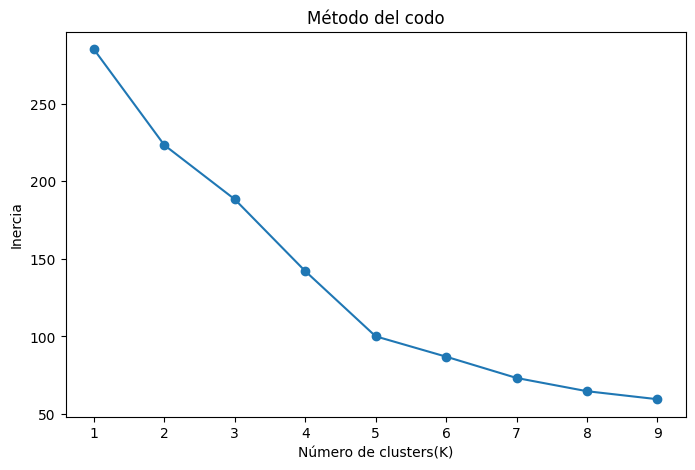

In [ ]:
# Para determinar el número óptimo de clusters empleamos el método del codo.
# 1. Calculamos las distancias cuadráticas(inercias) para los distintos valores de K

inercias = []
k_values = range(1, 10)

for k in k_values:
    labels, centroides, inercia = kmeans_numpy(X_scaled, k=k, random_state=42)
    inercias.append(inercia)

# 2. Visualizamos el gráfico del codo para poder tomar una decisión

plt.figure(figsize=(8,5))
plt.plot(k_values, inercias, marker='o')
plt.title("Método del codo")
plt.xlabel("Número de clusters(K)")
plt.ylabel("Inercia")
plt.xticks(k_values)
plt.show()

# Al visualizar el método del codo, se puede observar que con K=3 ya se captura una parte
# importante de la estructura de los datos. Es el punto donde la reducción de la inercia
# empieza a estabilizarse.


## Silhouette

k=2 → silhouette=0.2805
k=3 → silhouette=0.3064
k=4 → silhouette=0.3435
k=5 → silhouette=0.4185
k=6 → silhouette=0.4557
k=7 → silhouette=0.5049
k=8 → silhouette=0.4846
k=9 → silhouette=0.5257


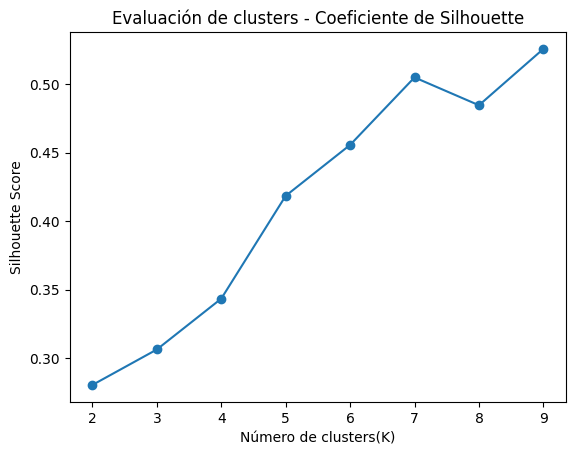

In [ ]:
# Definimos el cálculo de la variable para poderlo aplicar

def silhouette_score_manual(X, labels):
    n = X.shape[0]
    unique_clusters = np.unique(labels)
    silhouette_vals = []

    for i in range(n):
        same_cluster = labels == labels[i]
        other_clusters = labels != labels[i]

        # a(i): distancia media a su cluster
        if np.sum(same_cluster) > 1:
            a = np.mean(np.linalg.norm(X[i] - X[same_cluster], axis=1))
        else:
            a = 0

        # b(i): distancia mínima a otros clusters
        b = np.inf
        for cluster in unique_clusters:
            if cluster != labels[i]:
                cluster_points = X[labels == cluster]
                dist = np.mean(np.linalg.norm(X[i] - cluster_points, axis=1))
                b = min(b, dist)

        # silhouette
        s = (b - a) / max(a, b) if max(a, b) != 0 else 0
        silhouette_vals.append(s)

    return np.mean(silhouette_vals)

# Aplicamos el coeficiente de Silhouette al modelo

silhouette_scores = []
k_values = range(2, 10)

for k in k_values:
    labels, _, _ = kmeans_numpy(X_scaled, k=k, random_state=42)
    score = silhouette_score_manual(X_scaled.values, labels)
    silhouette_scores.append(score)


# Mostramos los resultados
for k, score in zip(k_values, silhouette_scores):
    print(f"k={k} → silhouette={score:.4f}")

# Visualizamos los resultados gráficamente

plt.plot(k_values, silhouette_scores, marker='o')
plt.xlabel("Número de clusters(K)")
plt.ylabel("Silhouette Score")
plt.title("Evaluación de clusters - Coeficiente de Silhouette")
plt.show()

# Tenemos en cuenta que el coeficiente de Silhoutte engaña cuando hay pocos datos

## Comparación del modelo final con K=3 y K=4

In [ ]:
# Modelo con K=3

k3 = 3
labels3, centroides3, inercia3 = kmeans_numpy(X_scaled, k=k3, random_state=42)
BaseFinal2["cluster_k3"] = labels3

# Modelo con K=4

k4 = 4
labels4, centroides4, inercia4 = kmeans_numpy(X_scaled, k=k4, random_state=42)
BaseFinal2["cluster_k4"] = labels4

# Comparamos ambos modelos

print("Inercia k=3:", inercia3)
print("Inercia k=4:", inercia4)

display(BaseFinal2[["ccaa", "cluster_k3", "cluster_k4"]])

# Comparamos el tamaño de los clusters

print("Tamaño clusters k=3")
print(BaseFinal2["cluster_k3"].value_counts())

print("\nTamaño clusters k=4")
print(BaseFinal2["cluster_k4"].value_counts())

Inercia k=3: 188.34055376260537
Inercia k=4: 142.1084730899488


,ccaa,cluster_k3,cluster_k4
0,Andalucia,0,0
1,Aragon,1,3
2,Asturias,1,3
3,Canarias,2,2
4,Cantabria,2,3
5,Castilla La Mancha,1,1
6,Castilla y Leon,2,3
7,Cataluña,0,0
8,Ceuta,1,1
9,Comunidad Valenciana,0,0


Tamaño clusters k=3
cluster_k3
2    9
1    7
0    3
Name: count, dtype: int64

Tamaño clusters k=4
cluster_k4
3    6
2    5
1    5
0    3
Name: count, dtype: int64


## Modelo Final K-Means (K=3)

In [ ]:
# Entenamos el modelo final con (K=3)

k_final = 3
labels, centroides, inercia_final = kmeans_numpy(X_scaled, k=k_final, random_state=42)

# Añadimos el cluster a la base original (Base Final 2)

BaseFinal2["cluster K=3"] = labels

print("Inercia final:", inercia_final)
display(BaseFinal2[["ccaa", "cluster K=3"]].sort_values("cluster K=3"))

# Comprobamos el tamaño de los clusters para ver que están equilibrados

BaseFinal2["cluster K=3"].value_counts()

# Mostramso el perfil medio de cada cluster para ir sacando conclusiones

BaseFinal2_model = BaseFinal2.drop(columns=["ccaa"])

cluster_summary = BaseFinal2_model.groupby("cluster K=3").mean(numeric_only=True)
display(cluster_summary)

Inercia final: 188.34055376260537


,ccaa,cluster K=3
0,Andalucia,0
7,Cataluña,0
9,Comunidad Valenciana,0
2,Asturias,1
5,Castilla La Mancha,1
10,Extremadura,1
8,Ceuta,1
1,Aragon,1
12,Islas Baleares,1
16,Murcia,1


,pct_centro_primaria,pct_centro_secundaria,gasto_reglado_medio,eso_concertado,eso_privado,eso_publico,pct_bach_privado,pct_bach_publico,pct_fpbasica_publico,pct_fpbasica_privado,pct_fpmedio_publico,pct_fpmedio_privado,pct_fpsuperior_publico,pct_fpsuperior_privado,renta_per_capita,cluster_k3,cluster_k4
cluster K=3,,,,,,,,,,,,,,,,,
0,16.657098,83.342902,1503.333333,92.800000,93.233333,84.733333,95.366667,87.633333,87.769513,12.230487,65.652716,34.347284,63.202816,36.797184,13451.333333,0.0,0.000000
1,70.027492,29.972508,7744.285714,91.285714,91.842857,84.442857,94.128571,84.442857,82.567586,17.432414,75.979058,24.020942,78.103747,21.896253,13198.857143,1.0,1.571429
2,65.123062,34.876938,1984.555556,94.200000,94.455556,86.877778,95.266667,87.644444,68.832286,31.167714,73.758183,26.241817,74.649795,25.350205,14805.888889,2.0,2.444444
